# Car-following MDP experiments

Run this Notebook from `week_02` after `python -m car_following init`. If the database already exists, use it directly. The following cells inspect the database, evaluate the initial policy, improve it once, run full policy iteration, and demonstrate both policies in HighwayEnv.

## Explore the database


In [1]:
%pwd

'C:\\Users\\flywi\\Desktop\\gitRepos\\neu-self-improve-ai\\week_02'

In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from sqlalchemy import inspect
from sqlalchemy.orm import Session

from car_following.database import open_engine, reflected_models

engine = open_engine(Path("output/car_following.sqlite3"))

In [3]:
table_names = [
    "environment",
    "state",
    "action",
    "transition",
    "policy",
    "policy_probability",
]

with engine.connect() as connection:
    for table_name in table_names:
        print(f"\n{table_name}: structure")
        display(pd.read_sql_query(
            f'PRAGMA table_info("{table_name}")',
            connection,
        ))

        print(f"{table_name}: first 5 rows")
        display(pd.read_sql_query(
            f'SELECT * FROM "{table_name}" ORDER BY rowid LIMIT 5',
            connection,
        ))


environment: structure


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,name,TEXT,1,None,0
2,2,specification_json,TEXT,1,None,0
3,3,initial_state_id,INTEGER,1,None,0


environment: first 5 rows


,id,name,specification_json,initial_state_id
0,1,Exact single-lane car following,"{""acceleration_mps2"": 6, ""close_reward"": -1, ""...",1980



state: structure


...

,id,name,description
0,1,uniform_initial,Each action has probability 1/3 at each nonter...



policy_probability: structure


,cid,name,type,notnull,dflt_value,pk
0,0,policy_id,INTEGER,1,None,1
1,1,state_id,INTEGER,1,None,2
2,2,action_id,INTEGER,1,None,3
3,3,policy_probability,REAL,1,None,0


policy_probability: first 5 rows


,policy_id,state_id,action_id,policy_probability
0,1,1,0,0.333333
1,1,1,1,0.333333
2,1,1,2,0.333333
3,1,2,0,0.333333
4,1,2,1,0.333333


In [4]:
base = reflected_models(engine)

for table_name in table_names:
    model_class = getattr(base.classes, table_name)
    print(table_name, "→", model_class)

environment → <class 'sqlalchemy.ext.automap.environment'>
state → <class 'sqlalchemy.ext.automap.state'>
action → <class 'sqlalchemy.ext.automap.action'>
transition → <class 'sqlalchemy.ext.automap.transition'>
policy → <class 'sqlalchemy.ext.automap.policy'>
policy_probability → <class 'sqlalchemy.ext.automap.policy_probability'>


In [5]:
State = base.classes.state

print("Python class:", State)
print("Database table:", State.__table__.name)

display(pd.DataFrame([
    {
        "attribute": column.key,
        "database_type": str(column.type),
        "primary_key": column.primary_key,
    }
    for column in inspect(State).columns
]))

Python class: <class 'sqlalchemy.ext.automap.state'>
Database table: state


,attribute,database_type,primary_key
0,id,INTEGER,True
1,gap_m,INTEGER,False
2,speed_mps,INTEGER,False
3,is_terminal,INTEGER,False


In [6]:
with Session(engine) as session:
    initial_state = session.get(State, 1980)

    print("Object type:", type(initial_state))
    print("id:", initial_state.id)
    print("gap_m:", initial_state.gap_m)
    print("speed_mps:", initial_state.speed_mps)
    print("is_terminal:", initial_state.is_terminal)

Object type: <class 'sqlalchemy.ext.automap.state'>
id: 1980
gap_m: 50
speed_mps: 20
is_terminal: 0


### The ORM object contains the same initial-state data as the SQL row


In [7]:
engine.dispose()

## Fixed-policy evaluation

Run these cells under directory `week_02` after initializing the database. Evaluate policy 1 (each action has probability 1/3) using the stored discount 0.9. All values start at zero. Each sweep uses the preceding sweep's values. The terminal value stays zero; terminal rewards are retained. The database and policy are not modified.

Stop when the maximum change per sweep is at most `1e-10`. This evaluates the continuing task, not a 20-step rollout.


In [8]:
from pathlib import Path
import pandas as pd
from car_following.evaluation import evaluate_policy

evaluation = evaluate_policy(Path("output/car_following.sqlite3"))
pd.DataFrame([
    {"metric": key, "value": f"{value:.12g}" if isinstance(value, float) else value}
    for key, value in evaluation["summary"].items()
])


,metric,value
0,policy_id,1
1,policy_name,uniform_initial
2,discount,0.9
3,iterations,127
4,tolerance,1e-10
5,max_change,9.13811248893e-11
6,bellman_residual,7.47331085904e-11
7,value_error_bound,7.47331085904e-10
8,initial_state_id,1980
9,initial_state_value,-17.4610027318


### State values

`value` is the expected discounted return under the fixed policy, not the immediate reward. The first table includes all 8,001 states (pandas abbreviates the display); the second selects the initial state.


In [9]:
values = pd.DataFrame(evaluation["values"])
display(values)
display(values.loc[values["state_id"] == evaluation["summary"]["initial_state_id"]])


,state_id,gap_m,speed_mps,is_terminal,value
0,0,NaN,NaN,1,0.000000
1,1,1.0,1.0,0,-15.064457
2,2,1.0,2.0,0,-15.305595
3,3,1.0,3.0,0,-15.891783
4,4,1.0,4.0,0,-16.605431
...,...,...,...,...,...
7996,7996,200.0,36.0,0,-8.137023
7997,7997,200.0,37.0,0,-8.172547
7998,7998,200.0,38.0,0,-8.199673
7999,7999,200.0,39.0,0,-8.402987


,state_id,gap_m,speed_mps,is_terminal,value
1980,1980,50.0,20.0,0,-17.461003


### Iteration history

One iteration updates all 8,000 nonterminal states. `max_change` is the largest absolute value change in that sweep. The initial state's first-sweep value is 1 because all three immediate rewards are +1 and all previous values are zero. Later sweeps include subsequent rewards and penalties.


In [10]:
history = pd.DataFrame(evaluation["history"])
display(pd.concat([history.head(5), history.tail(5)]).drop_duplicates("iteration"))


,iteration,max_change,initial_state_value
0,1,1.000000e+02,1.000000
1,2,8.010000e+01,1.700000
2,3,3.663000e+01,2.090000
3,4,2.115900e+01,2.009000
4,5,1.272780e+01,-0.898900
122,123,2.041460e-10,-17.461003
123,124,1.670006e-10,-17.461003
124,125,1.365965e-10,-17.461003
125,126,1.117169e-10,-17.461003
126,127,9.138112e-11,-17.461003


### Initial-state calculation

For initial gap 50 m and following speed 20 m/s, show each action's reward, discounted continuation, and policy-weighted contribution. `action_value` means taking that action once and following the fixed policy thereafter. Their weighted sum reproduces the initial state value up to the reported numerical residual. No action is selected or improved here.


In [11]:
import sqlite3

database_path = Path("output/car_following.sqlite3").resolve()
connection = sqlite3.connect(database_path.as_uri() + "?mode=ro", uri=True)
try:
    contributions = pd.read_sql_query("""
        SELECT a.name AS action, p.policy_probability,
               t.reward, t.next_state_id
        FROM transition t
        JOIN action a ON a.id = t.action_id
        JOIN policy_probability p
          ON p.state_id = t.state_id AND p.action_id = t.action_id
        WHERE t.state_id = ? AND p.policy_id = ?
        ORDER BY a.id
    """, connection, params=(evaluation["summary"]["initial_state_id"],
                             evaluation["summary"]["policy_id"]))
finally:
    connection.close()

value_by_id = values.set_index("state_id")["value"]
contributions["next_state_value"] = contributions["next_state_id"].map(value_by_id)
contributions["discounted_continuation"] = (
    evaluation["summary"]["discount"] * contributions["next_state_value"]
)
contributions["action_value"] = contributions["reward"] + contributions["discounted_continuation"]
contributions["weighted_contribution"] = (
    contributions["policy_probability"] * contributions["action_value"]
)
display(contributions)
print("Sum of contributions:", contributions["weighted_contribution"].sum())
print("Evaluated initial value:", evaluation["summary"]["initial_state_value"])


,action,policy_probability,reward,next_state_id,next_state_value,discounted_continuation,action_value,weighted_contribution
0,accelerate,0.333333,1.0,1866,-35.181715,-31.663543,-30.663543,-10.221181
1,maintain,0.333333,1.0,1980,-17.461003,-15.714902,-14.714902,-4.904967
2,decelerate,0.333333,1.0,2094,-8.893958,-8.004562,-7.004562,-2.334854


Sum of contributions: -17.461002731894943
Evaluated initial value: -17.461002731829034


### Results: initial policy

The uniform policy chooses each action with probability 1/3 at every nonterminal state. Its evaluation converges after **127 value-update sweeps**. At the initial state (gap 50 m, following speed 20 m/s), its expected discounted return is approximately **-17.461003**.

All three immediate rewards at this state are +1. The negative state value comes from subsequent rewards and failure penalties under the uniform policy. It does not mean the first action receives a negative reward.

The action values in the table are approximately -30.663543 (accelerate), -14.714902 (maintain), and -7.004562 (decelerate). Each value assumes that the named action is taken once and the uniform policy is followed thereafter. Their equal-weighted sum reproduces the evaluated state value within numerical tolerance. Evaluation alone leaves the action probabilities unchanged.

The Bellman residual is approximately `7.47e-11`, giving a value-error bound of `7.47e-10` relative to the exact value of this fixed uniform policy. A small evaluation residual confirms numerical convergence; it does not establish that the policy is optimal.


## One-step policy improvement

Run from `week_02`. This section evaluates the stored initial policy, improves it once, and evaluates the new policy. It recomputes its inputs and can run independently of the earlier evaluation cells. The database and initial policy are preserved; the improved policy exists only in memory. Re-running starts from the initial policy again.

Action values use the initial policy's state values. The new policy assigns equal probability to actions within `1e-10` of the highest action value. Both evaluations start from zero with discount 0.9 and stop at a maximum sweep change of `1e-10`.

A single input `tolerance=1e-10` sets both the evaluation stopping threshold and the action-value tie threshold.


In [12]:
from pathlib import Path
import pandas as pd
from IPython.display import display
from car_following.improvement import improve_policy

improvement = improve_policy(Path("output/car_following.sqlite3"))
pd.DataFrame([
    {"metric": key, "value": f"{value:.12g}" if isinstance(value, float) else value}
    for key, value in improvement["summary"].items()
])


,metric,value
0,improvement_rounds,1
1,initial_state_id,1980
2,discount,0.9
3,action_value_tie_tolerance,1e-10
4,state_value_convergence_tolerance,1e-10
5,changed_states,7775
6,initial_state_value_before,-17.4610027318
7,initial_state_value_after,9.99999999914
8,initial_state_value_gain,27.461002731
9,minimum_value_gain,0


### Initial-state action probabilities

Initial state: gap 50 m, following speed 20 m/s. `action_value` takes the named action once, then follows the INITIAL policy. These values select the improved policy; they are not action values re-evaluated under the new policy. `initial_policy_probability` and `improved_policy_probability` show the change in action selection.


In [13]:
action_comparison = pd.DataFrame(improvement["action_values"])
initial_state_id = improvement["summary"]["initial_state_id"]
display(action_comparison.loc[
    action_comparison["state_id"] == initial_state_id,
    ["action", "reward", "next_state_id", "initial_next_state_value",
     "action_value", "initial_policy_probability", "improved_policy_probability"],
])


,action,reward,next_state_id,initial_next_state_value,action_value,initial_policy_probability,improved_policy_probability
5937,accelerate,1.0,1866,-35.181715,-30.663543,0.333333,0.0
5938,maintain,1.0,1980,-17.461003,-14.714902,0.333333,0.0
5939,decelerate,1.0,2094,-8.893958,-7.004562,0.333333,1.0


### State-value comparison

The initial value follows the initial policy at every step. The improved value follows the improved policy at every step, not just for the first action. The first table selects the initial state; the second contains all 8,001 states (including terminal state 0). `value_gain` is improved minus initial value.


In [14]:
value_comparison = pd.DataFrame(improvement["value_comparison"])
display(value_comparison.loc[value_comparison["state_id"] == initial_state_id])
display(value_comparison)
print("States with lower value beyond comparison tolerance:",
      improvement["summary"]["states_with_lower_value"])


,state_id,gap_m,speed_mps,is_terminal,initial_value,improved_value,value_gain
1980,1980,50.0,20.0,0,-17.461003,10.0,27.461003


,state_id,gap_m,speed_mps,is_terminal,initial_value,improved_value,value_gain
0,0,NaN,NaN,1,0.000000,0.000000,0.000000
1,1,1.0,1.0,0,-15.064457,2.713216,17.777673
2,2,1.0,2.0,0,-15.305595,1.895328,17.200923
3,3,1.0,3.0,0,-15.891783,1.895328,17.787111
4,4,1.0,4.0,0,-16.605431,2.325795,18.931226
...,...,...,...,...,...,...,...
7996,7996,200.0,36.0,0,-8.137023,0.000000,8.137023
7997,7997,200.0,37.0,0,-8.172547,0.000000,8.172547
7998,7998,200.0,38.0,0,-8.199673,0.000000,8.199673
7999,7999,200.0,39.0,0,-8.402987,0.000000,8.402987


States with lower value beyond comparison tolerance: 0


### Improved-policy evaluation

A new policy is held fixed throughout these evaluation sweeps. These are value-update iterations, not additional policy-improvement rounds. `policy_id` is empty because this policy was not inserted into the database. Only one greedy improvement is performed.


In [15]:
improved_evaluation = improvement["improved_evaluation"]
display(pd.DataFrame([
    {"metric": key, "value": f"{value:.12g}" if isinstance(value, float) else value}
    for key, value in improved_evaluation["summary"].items()
]))
improved_history = pd.DataFrame(improved_evaluation["history"])
display(pd.concat([improved_history.head(5), improved_history.tail(5)])
        .drop_duplicates("iteration"))


,metric,value
0,policy_id,None
1,policy_name,greedy_once_from_initial
2,discount,0.9
3,iterations,220
4,tolerance,1e-10
5,max_change,9.53042089691e-11
6,bellman_residual,8.57740545257e-11
7,value_error_bound,8.57740545257e-10
8,initial_state_id,1980
9,initial_state_value,9.99999999914


,iteration,max_change,initial_state_value
0,1,1.000000e+02,1.0000
1,2,9.000000e+01,1.9000
2,3,4.050000e+01,2.7100
3,4,7.290000e-01,3.4390
4,5,6.561000e-01,4.0951
215,216,1.452598e-10,10.0000
216,217,1.307328e-10,10.0000
217,218,1.176605e-10,10.0000
218,219,1.058940e-10,10.0000
219,220,9.530421e-11,10.0000


### Results: one policy improvement

Using the initial policy's evaluated state values, one greedy improvement changes action probabilities at **7,775 of the 8,000 nonterminal states**. At the initial state, deceleration has the highest action value, so its probability becomes 1 and the other two probabilities become 0.

Holding this improved policy fixed and evaluating it again gives an initial-state value of approximately **10.0**, an increase of **27.461003**. This value follows the improved policy at every subsequent state; it is not the earlier deceleration action value of -7.004562, which assumed the uniform policy afterward.

No nonterminal state has a value decrease exceeding the comparison tolerance of approximately `2.61e-9`. This check allows for the two evaluations' numerical error bounds and the action-value tie tolerance.

The highest one-step reward is +1 and the discount is 0.9, so the continuing discounted return cannot exceed `1 / (1 - 0.9) = 10`. The improved policy reaches this bound numerically at the initial state. This alone does not establish optimality at all other states; full policy iteration checks those states as well.


## Full policy iteration

Run from `week_02`. This experiment starts from the stored uniform policy and repeatedly evaluates and improves it. The database is not modified. Round 0 evaluates the initial policy; `changed_states` counts changes proposed AFTER evaluating that row's policy. A final zero means the next greedy step leaves the policy unchanged. `evaluation_sweeps` counts value updates within one fixed-policy evaluation, not policy updates.

`policy_residual` checks the current policy's Bellman equation. `optimality_residual` compares each state value with its maximum action value and takes the largest absolute difference. Stop only when the policy is stable and this residual is at most `action_value_tie_tolerance + state_value_convergence_tolerance` (`2e-10` by default). `optimal_value_error_bound` bounds value error relative to this MDP's optimal state values.


In [16]:
from pathlib import Path
import pandas as pd
from IPython.display import display
from car_following.improvement import iterate_policy

policy_iteration = iterate_policy(Path("output/car_following.sqlite3"))
display(pd.DataFrame([
    {"metric": key, "value": f"{value:.12g}" if isinstance(value, float) else value}
    for key, value in policy_iteration["summary"].items()
]))
display(pd.DataFrame(policy_iteration["history"]))


,metric,value
0,converged,True
1,policy_stable,True
2,improvement_rounds,6
3,evaluated_policies,7
4,initial_state_id,1980
5,initial_state_value_before,-17.4610027318
6,initial_state_value_after,9.99999999914
7,discount,0.9
8,action_value_tie_tolerance,1e-10
9,state_value_convergence_tolerance,1e-10


,improvement_round,evaluation_sweeps,initial_state_value,changed_states,policy_residual,optimality_residual
0,0,127,-17.461003,7775,7.473311e-11,6.000000e+01
1,1,220,10.000000,6094,8.577405e-11,2.000000e+01
2,2,220,10.000000,5218,8.577850e-11,7.085880e+00
3,3,220,10.000000,1116,8.577583e-11,3.078000e+00
4,4,220,10.000000,328,8.577539e-11,1.385100e+00
5,5,220,10.000000,27,8.577539e-11,8.577539e-11
6,6,220,10.000000,0,8.577539e-11,8.577539e-11


### Final action probabilities at the initial state

Initial state: gap 50 m, following speed 20 m/s. Here `action_value` uses the FINAL policy's state values, unlike the earlier one-step improvement table, which uses the initial policy's values. Probabilities are split equally among actions within `1e-10` of the maximum.


In [17]:
final_actions = pd.DataFrame(policy_iteration["action_values"])
initial_state_id = policy_iteration["summary"]["initial_state_id"]
display(final_actions.loc[final_actions["state_id"] == initial_state_id, [
    "action", "action_value", "initial_policy_probability", "final_policy_probability"
]])


,action,action_value,initial_policy_probability,final_policy_probability
5937,accelerate,10.0,0.333333,0.333333
5938,maintain,10.0,0.333333,0.333333
5939,decelerate,10.0,0.333333,0.333333


### Initial versus final state values

Both columns are continuing-task discounted values, not 20-step returns. The first table shows the initial state; the second contains every state. The initial-state value can stop changing before the policy is stable across all other states.


In [18]:
iteration_value_comparison = pd.DataFrame(policy_iteration["value_comparison"])
display(iteration_value_comparison.loc[
    iteration_value_comparison["state_id"] == initial_state_id
])
display(iteration_value_comparison)


,state_id,gap_m,speed_mps,is_terminal,initial_value,final_value,value_gain
1980,1980,50.0,20.0,0,-17.461003,10.0,27.461003


,state_id,gap_m,speed_mps,is_terminal,initial_value,final_value,value_gain
0,0,NaN,NaN,1,0.000000,0.000000,0.000000
1,1,1.0,1.0,0,-15.064457,6.200000,21.264457
2,2,1.0,2.0,0,-15.305595,6.200000,21.505595
3,3,1.0,3.0,0,-15.891783,6.200000,22.091783
4,4,1.0,4.0,0,-16.605431,6.200000,22.805431
...,...,...,...,...,...,...,...
7996,7996,200.0,36.0,0,-8.137023,4.782969,12.919992
7997,7997,200.0,37.0,0,-8.172547,4.782969,12.955516
7998,7998,200.0,38.0,0,-8.199673,5.314410,13.514083
7999,7999,200.0,39.0,0,-8.402987,5.314410,13.717397


### Results: full policy iteration

Starting from the uniform policy, the experiment completes **6 policy updates and 7 policy evaluations**. Round 0 evaluates the initial policy. The numbers of states whose probabilities would change in the next greedy step are `7775, 6094, 5218, 1116, 328, 27, 0`. The final zero confirms that another greedy step leaves the policy unchanged within the probability-comparison tolerance.

The initial-state value remains approximately 10 after the first improvement, but other states continue to improve. For example, state 1 (gap 1 m, following speed 1 m/s) has value approximately **2.713216** after one improvement and **6.2** under the final policy. This explains why checking only the initial state would stop too early.

At the initial state, all three final action values are approximately 10 and tied within `1e-10`, so the final policy assigns each action probability 1/3. This does not restore the original uniform policy across all states. These action values use the final policy's state values, and subsequent actions follow that final policy. The original action values instead assumed uniform action selection at every subsequent state.

The final Bellman optimality residual is approximately **`8.58e-11`**, below the stopping threshold of `2e-10`. Its corresponding error bound is approximately **`8.58e-10`** relative to this MDP's optimal state values. Together with policy stability, this supports convergence within the specified numerical tolerances across all 8,000 nonterminal states.

These results evaluate the continuing discounted task using the stored deterministic transitions. They are not measured 20-step driving trajectories. The improved policies and calculated values remain in memory; the database retains the original uniform policy.


## HighwayEnv policy demonstration

Run after **Full policy iteration**. Both demonstrations start at gap 50 m and following speed 20 m/s, with the lead vehicle at 20 m/s. They use seed 0 to sample actions from their respective policies and stop after a failure or 20 decisions. The final demonstration reuses `policy_iteration` computed above.

HighwayEnv supplies the road, vehicle objects and rendering. The custom vehicle update preserves our exact constant-acceleration rule; the MDP supplies the first failure time and reward. Each simulated transition is checked against SQLite. Blue is the following vehicle and green is the lead vehicle.

`sample_discounted_return` is the discounted sum from this sampled, possibly truncated trajectory. It is not the continuing expected state value. `terminated` means task failure; `truncated` means the 20-decision demonstration cap was reached without failure.


In [19]:
from car_following.simulation import run_simulation

initial_drive = run_simulation(
    Path("output/car_following.sqlite3"), policy="initial", seed=0, capture_frames=True,
)
final_drive = run_simulation(
    Path("output/car_following.sqlite3"), policy="final", seed=0,
    capture_frames=True, iteration_result=policy_iteration,
)

display(pd.DataFrame([initial_drive["summary"], final_drive["summary"]]))


,policy,seed,decisions,total_reward,sample_discounted_return,terminated,truncated,terminal_reason,time_seconds,sql_transitions_match
0,initial,0,6,-101.0,-59.344100,True,False,collision,5.845299,True
1,final,0,20,20.0,8.784233,False,True,None,20.000000,True


### Observed trajectories

Each row is one decision. `policy_probability` is the probability of the action actually sampled. The environment's transition remains deterministic given the state and action. The last row reports whether the demonstration ended through failure or the time limit.


In [20]:
initial_trajectory = pd.DataFrame(initial_drive["trajectory"])
final_trajectory = pd.DataFrame(final_drive["trajectory"])
print("Initial policy")
display(initial_trajectory)
print("Final policy")
display(final_trajectory)


Initial policy


,decision,state_id,gap_before_m,speed_before_mps,action,policy_probability,reward,next_state_id,gap_after_m,speed_after_mps,elapsed_seconds,time_seconds,terminated,truncated,terminal_reason
0,1,1980,50.0,20.0,maintain,0.333333,1.0,1980,50.0,20.000000,1.000000,1.000000,False,False,None
1,2,1980,50.0,20.0,accelerate,0.333333,1.0,1866,47.0,26.000000,1.000000,2.000000,False,False,None
2,3,1866,47.0,26.0,accelerate,0.333333,-1.0,1512,38.0,32.000000,1.000000,3.000000,False,False,None
3,4,1512,38.0,32.0,accelerate,0.333333,-1.0,918,23.0,38.000000,1.000000,4.000000,False,False,None
4,5,918,23.0,38.0,decelerate,0.333333,-1.0,312,8.0,32.000000,1.000000,5.000000,False,False,None
5,6,312,8.0,32.0,decelerate,0.333333,-100.0,0,0.0,26.928203,0.845299,5.845299,True,False,collision


Final policy


,decision,state_id,gap_before_m,speed_before_mps,action,policy_probability,reward,next_state_id,gap_after_m,speed_after_mps,elapsed_seconds,time_seconds,terminated,truncated,terminal_reason
0,1,1980,50.0,20.0,maintain,0.333333,1.0,1980,50.0,20.0,1.0,1.0,False,False,None
1,2,1980,50.0,20.0,accelerate,0.333333,1.0,1866,47.0,26.0,1.0,2.0,False,False,None
2,3,1866,47.0,26.0,decelerate,1.000000,1.0,1740,44.0,20.0,1.0,3.0,False,False,None
3,4,1740,44.0,20.0,maintain,0.500000,1.0,1740,44.0,20.0,1.0,4.0,False,False,None
4,5,1740,44.0,20.0,decelerate,0.500000,1.0,1854,47.0,14.0,1.0,5.0,False,False,None
5,6,1854,47.0,14.0,decelerate,0.333333,1.0,2208,56.0,8.0,1.0,6.0,False,False,None
6,7,2208,56.0,8.0,maintain,0.500000,1.0,2688,68.0,8.0,1.0,7.0,False,False,None
7,8,2688,68.0,8.0,accelerate,1.000000,1.0,3054,77.0,14.0,1.0,8.0,False,False,None
8,9,3054,77.0,14.0,accelerate,1.000000,1.0,3180,80.0,20.0,1.0,9.0,False,False,None
9,10,3180,80.0,20.0,maintain,0.500000,1.0,3180,80.0,20.0,1.0,10.0,False,False,None


### Gap, speed and vehicle animations

The curves include the initial state and each decision's actual ending time. The shaded gap band is the +1 reward range, 40 to 80 m. The dashed speed line is the lead vehicle's constant 20 m/s.

The animations use HighwayEnv-rendered frames at five substeps per second. Their camera follows the blue vehicle; the title shows elapsed simulation time. Use the play controls to compare the two policies. A single sampled trajectory illustrates behaviour and does not replace the expected-value calculations above.


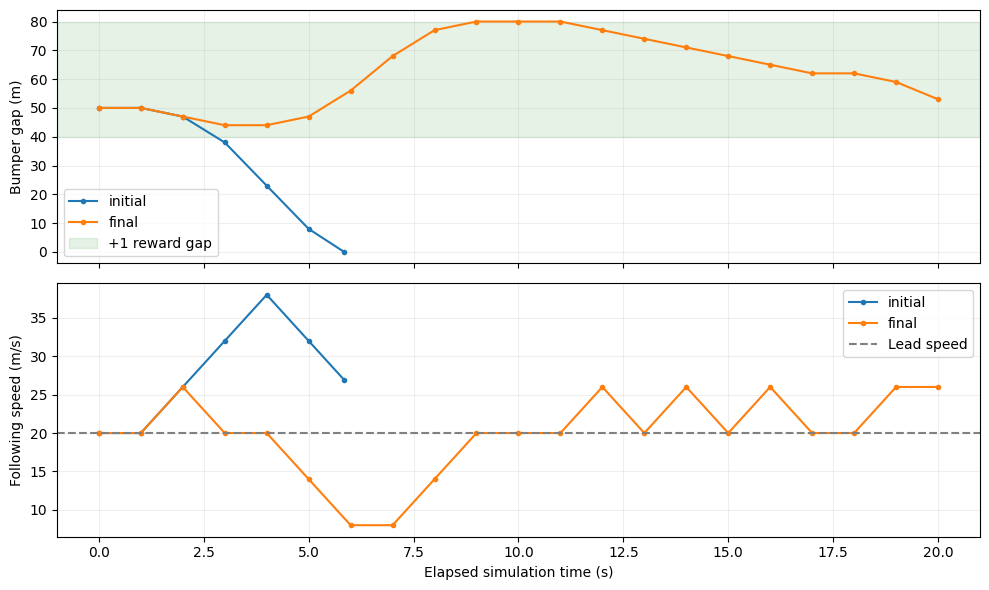

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for drive in (initial_drive, final_drive):
    rows = drive["trajectory"]
    times = [0.0] + [row["time_seconds"] for row in rows]
    gaps = [50.0] + [row["gap_after_m"] for row in rows]
    speeds = [20.0] + [row["speed_after_mps"] for row in rows]
    label = drive["summary"]["policy"]
    axes[0].plot(times, gaps, marker=".", label=label)
    axes[1].plot(times, speeds, marker=".", label=label)
axes[0].axhspan(40, 80, color="green", alpha=0.1, label="+1 reward gap")
axes[0].set_ylabel("Bumper gap (m)")
axes[1].axhline(20, color="grey", linestyle="--", label="Lead speed")
axes[1].set_ylabel("Following speed (m/s)")
axes[1].set_xlabel("Elapsed simulation time (s)")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.2)
fig.tight_layout()
display(fig)
plt.close(fig)


In [22]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation


def show_drive(drive):
    fig, axis = plt.subplots(figsize=(10, 2.6))
    picture = axis.imshow(drive["frames"][0])
    axis.set_axis_off()
    title = axis.set_title("")

    def update(frame_index):
        picture.set_data(drive["frames"][frame_index])
        time_seconds = drive["frame_times"][frame_index]
        title.set_text(f"{drive['summary']['policy'].title()} policy | t = {time_seconds:.2f} s")
        return picture, title

    animation = FuncAnimation(fig, update, frames=len(drive["frames"]), interval=200)
    html = animation.to_jshtml()
    plt.close(fig)
    display(HTML(html))


show_drive(initial_drive)
show_drive(final_drive)


### Demonstration results (seed 0)

The initial policy collides during decision 6, at approximately **5.8453 seconds**. Its total reward is **-101** and its sampled discounted return is **-59.3441**. This is one observed trajectory; it need not equal the initial policy's expected value of -17.4610.

The final policy completes **20 decisions without failure**, receiving +1 at each decision. Its total reward is **20** and its sampled discounted return is approximately **8.784233**. The remaining discounted continuation after the display cap is not included in this sample return, so it is lower than the continuing-task value of 10.

Both trajectories match the SQL transition records at every step. The animation executes the existing policies in a custom HighwayEnv environment; it does not train another policy or measure success rates across multiple random seeds.
